In [1]:
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import torchaudio
import torch.nn.functional as F
import kagglehub
import cv2
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Sample rate after Resampling: 16000


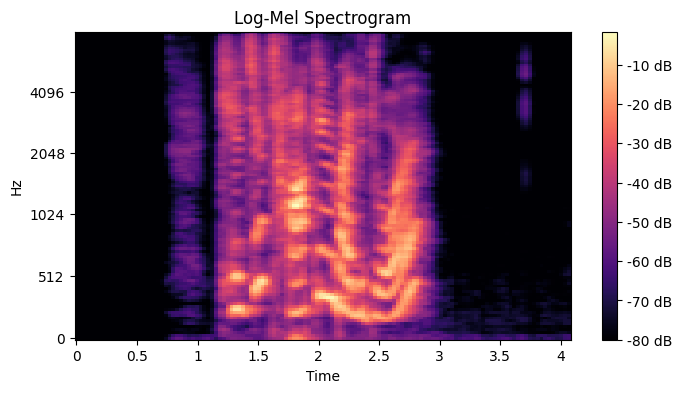

In [2]:
# Preprocessing for CNN

path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

wav = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".wav"):
            wav.append(os.path.join(root, file))

path = wav[0]

audio, sr = librosa.load(path, sr=16000) # using 16k because its the standard for nlp
print(f"Sample rate after Resampling: {sr}")

target_length = 3 * 16000

def padding(audio, target_length):
    if len(audio) > target_length:
        audio = audio[:target_length]
    else:
        audio = F.pad(audio, (0, target_length - len(audio)))
    return audio

padding(audio, target_length)

def logmel_spectrogram(y, sr, n_mels=128, hop_length=512):
    mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    logmel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    logmel_spectrogram = cv2.resize(
        logmel_spectrogram,
        (128, 128)
    )
    return logmel_spectrogram

ls = logmel_spectrogram(audio, sr=16000)

plt.figure(figsize=(8, 4))
librosa.display.specshow(ls, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram')
plt.show()


In [ ]:
print(wav)

['/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-02-02-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-05-01-01-02-02.wav', '/kaggle/input/

In [ ]:
!pip install openai-whisper
import whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=c4af2e292fe34b83811e5e7d6a42280e0ffeb138964c3ebda91a851a2c523ac2
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [ ]:
'''
model = whisper.load_model("base")

transcriptions = []
for audio_path in wav[:500]: # started with 10 to test
    result = model.transcribe(audio_path)
    transcriptions.append({
        "file": os.path.basename(audio_path),
        "text": result["text"].strip()
    })

with open("transcript.txt", "w", encoding="utf-8") as f:
    for item in transcriptions:
        f.write(f"{item['file']}: {item['text']}\n")
'''

'\nmodel = whisper.load_model("base")\n\ntranscriptions = []\nfor audio_path in wav[:500]: # started with 10 to test\n    result = model.transcribe(audio_path)\n    transcriptions.append({\n        "file": os.path.basename(audio_path),\n        "text": result["text"].strip()\n    })\n\nwith open("transcript.txt", "w", encoding="utf-8") as f:\n    for item in transcriptions:\n        f.write(f"{item[\'file\']}: {item[\'text\']}\n")\n'

In [ ]:
'''
!pip install transformers

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
with open("transcript.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

texts = [line.split(":", 1)[1].strip() for line in lines if ":" in line]
tokenized = tokenizer(
    texts,
    padding='max_length', # pad to longest in batch
    truncation=True, # truncate if over max_length
    max_length=128,
    return_tensors="pt"  # return PyTorch tensors
)
'''

'\n!pip install transformers\n\ntokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")\nwith open("transcript.txt", "r", encoding="utf-8") as f:\n    lines = f.readlines()\n\ntexts = [line.split(":", 1)[1].strip() for line in lines if ":" in line]\ntokenized = tokenizer(\n    texts,\n    padding=\'max_length\', # pad to longest in batch\n    truncation=True, # truncate if over max_length\n    max_length=128,\n    return_tensors="pt"  # return PyTorch tensors\n)\n'

In [3]:
#HARDCODE
def get_transcript(filepath):
    filename = os.path.basename(filepath)
    statement = filename.split("-")[4]   # 5th field

    if statement == "01":
        return "kids are talking by the door"
    else:
        return "dogs are sitting by the door"

transcripts = [get_transcript(f) for f in wav]

In [4]:
import torch
#mapping emotions and loading using librosa

emotions=[]

#Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fear, 07 = disgust, 08 = surprised)
for file in wav:
    if file.split('-')[5] == '01':
        emotions.append("neutral")
    elif file.split('-')[5] == '02':
        emotions.append("calm")
    elif file.split('-')[5] == '03':
        emotions.append("happy")
    elif file.split('-')[5] == '04':
        emotions.append("sad")
    elif file.split('-')[5] == '05':
        emotions.append("angry")
    elif file.split('-')[5] == '06':
        emotions.append("fear")
    elif file.split('-')[5] == '07':
        emotions.append("disgust")
    elif file.split('-')[5] == '08':
        emotions.append("surprised")

print(emotions)

fts = []

for file in wav:
    x, sr = librosa.load(file,duration=3,sr=16000,offset=0.5)
    x = torch.from_numpy(x)
    x = padding(x, target_length)
    mel = logmel_spectrogram(x.numpy(), sr=16000)
    fts.append(mel)

X = np.array(fts)
X = (X-X.min())/(X.max()-X.min())
X = (X - X.mean(axis=(1,2), keepdims=True))/(X.std(axis=(1,2), keepdims=True) + 1e-8)
X = np.expand_dims(X, axis=-1)


['surprised', 'neutral', 'disgust', 'disgust', 'neutral', 'fear', 'sad', 'neutral', 'calm', 'happy', 'disgust', 'angry', 'happy', 'fear', 'surprised', 'fear', 'fear', 'calm', 'sad', 'happy', 'disgust', 'surprised', 'angry', 'happy', 'fear', 'angry', 'angry', 'angry', 'surprised', 'calm', 'surprised', 'happy', 'calm', 'angry', 'angry', 'happy', 'sad', 'disgust', 'sad', 'calm', 'fear', 'calm', 'surprised', 'disgust', 'calm', 'fear', 'happy', 'fear', 'angry', 'neutral', 'sad', 'sad', 'disgust', 'surprised', 'surprised', 'calm', 'sad', 'sad', 'happy', 'disgust', 'calm', 'angry', 'happy', 'calm', 'disgust', 'calm', 'happy', 'calm', 'surprised', 'angry', 'disgust', 'neutral', 'sad', 'surprised', 'happy', 'surprised', 'fear', 'fear', 'surprised', 'angry', 'sad', 'angry', 'happy', 'angry', 'angry', 'disgust', 'happy', 'disgust', 'disgust', 'sad', 'neutral', 'fear', 'neutral', 'happy', 'disgust', 'fear', 'calm', 'angry', 'fear', 'surprised', 'fear', 'fear', 'sad', 'calm', 'sad', 'happy', 'sad',

In [5]:
lb = LabelEncoder()
y_encoded = lb.fit_transform(emotions)  # angry→0, calm→1 etc.

df = pd.DataFrame({
    'label': y_encoded,
    'transcript': transcripts
})

df['feats'] = np.arange(len(X))

neutral_class = lb.transform(['neutral'])[0]
neutral_df = df[df['label'] == neutral_class]
other_df = df[df['label'] != neutral_class]

print(len(neutral_df)) # too many neutral samples --> need to be undersampled to 192

# undersampling neutral class
neutral_downsampled = neutral_df.sample(
    n=192,
    random_state=42
)
bal_df = pd.concat([
    neutral_downsampled,
    other_df
])

print(len(neutral_downsampled))

# shuffle
bal_df = bal_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

select = bal_df['feats'].values

X_bal = X[select]
y_bal = bal_df['label'].values
transcripts_bal = bal_df['transcript'].tolist()

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, stratify=y_bal, test_size=0.2, random_state=42
)

# label map
y_lb_encoded = dict(enumerate(lb.classes_))

# checking shapes of data
#print(f'X_train shape: {X_train.shape}')
#print(f'y_train shape: {y_train.shape}')
#print(f'X_test shape: {X_test.shape}')
#print(f'y_test shape: {y_test.shape}')


1536
192


In [12]:
#x_traincnn = np.expand_dims(X_train_scaled, axis=2)
#x_testcnn = np.expand_dims(X_test_scaled, axis=2)

CNN_model = Sequential()
CNN_model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    input_shape=(128,128,1)
))
CNN_model.add(BatchNormalization())
CNN_model.add(MaxPooling2D((2,2)))
CNN_model.add(Dropout(0.1))
CNN_model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))
CNN_model.add(BatchNormalization())
CNN_model.add(MaxPooling2D((2,2)))
CNN_model.add(Dropout(0.3))
CNN_model.add(Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
))
CNN_model.add(MaxPooling2D((2,2)))
CNN_model.add(Dropout(0.3))
CNN_model.add(Conv2D(
    256,
    (3,3),
    activation='relu',
    padding='same'
))
CNN_model.add(MaxPooling2D((2,2)))
CNN_model.add(Dropout(0.4))
CNN_model.add(Flatten())
CNN_model.add(Dense(256, activation='relu'))
CNN_model.add(Dropout(0.4))
CNN_model.add(Dense(8, activation='softmax'))

CNN_model.compile(
    optimizer=Adam(learning_rate=0.0001),  # lowering lr
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

CNN_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,584,840 (17.49 MB)

 Trainable params: 4,584,648 (17.49 MB)

 Non-trainable params: 192 (768.00 B)

In [13]:
# Train
results = CNN_model.fit(X_train, y_train,
    epochs=50,
    batch_size=32,
    verbose =1,
    validation_data=(X_test, y_test)
 )

# Evaluate
loss, accuracy = CNN_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 203ms/step - accuracy: 0.1507 - loss: 2.9167 - val_accuracy: 0.2110 - val_loss: 2.0763
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1572 - loss: 2.0646 - val_accuracy: 0.2045 - val_loss: 2.0748
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1743 - loss: 2.0462 - val_accuracy: 0.2078 - val_loss: 2.0687
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1897 - loss: 2.0219 - val_accuracy: 0.1948 - val_loss: 2.0669
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2158 - loss: 2.0015 - val_accuracy: 0.1721 - val_loss: 2.0571
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2264 - loss: 1.9821 - val_accuracy: 0.2175 - val_loss: 2.0517
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2305 - loss: 1.9421 - val_accuracy: 0.2825 - val_loss: 2.0272
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2524 - loss: 1.9381 - val_accuracy: 0.2403 -

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
              precision    recall  f1-score   support

       angry       0.68      0.71      0.69        38
        calm       0.60      0.95      0.73        38
     disgust       0.60      0.72      0.65        39
        fear       0.56      0.77      0.65        39
       happy       0.56      0.23      0.33        39
     neutral       0.25      0.05      0.09        38
         sad       0.61      0.44      0.51        39
   surprised       0.62      0.89      0.73        38

    accuracy                           0.59       308
   macro avg       0.56      0.59      0.55       308
weighted avg       0.56      0.59      0.55       308



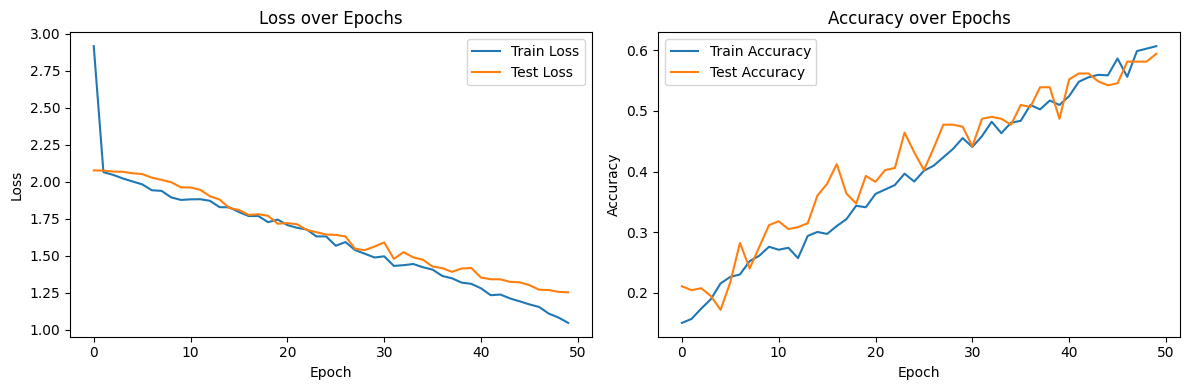

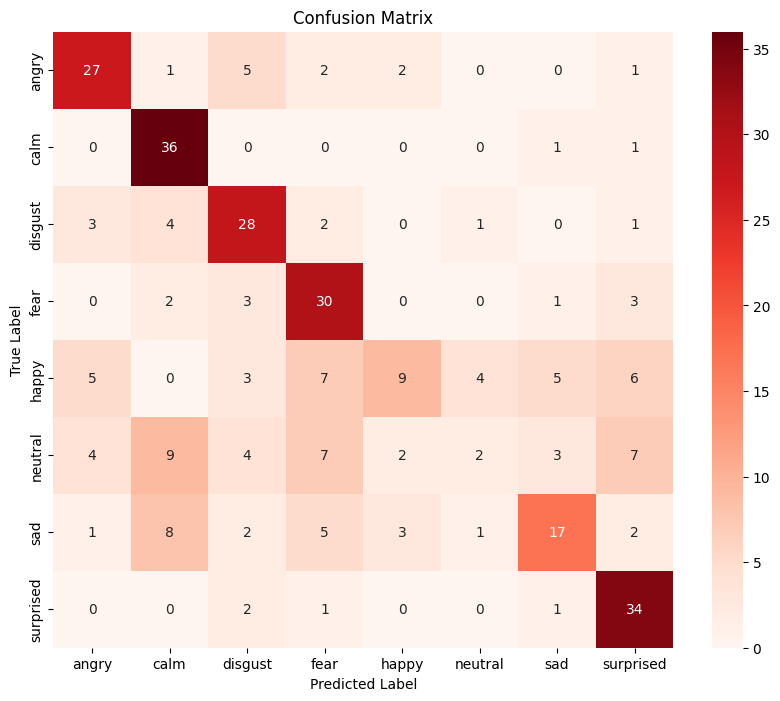

In [14]:
# Visualising predictions versus actual labels

y_pred = np.argmax(CNN_model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=lb.classes_))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(results.history['loss'], label='Train Loss')
plt.plot(results.history['val_loss'], label='Test Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results.history['accuracy'], label='Train Accuracy')
plt.plot(results.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Confusion matrix heatmap - looking for diagonal dominance
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=lb.classes_,
            yticklabels=lb.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [15]:
# Preprocessing for RNN

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

tokenized = tokenizer(
    transcripts_bal,
    padding='max_length',
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

X_text = tokenized['input_ids'].numpy()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [16]:
vocab_size = tokenizer.vocab_size
embed_dim = 128
hidden_dim = 256
num_classes = 8 # there are 8 emotions so we can write this directly
max_length = 128

# Embedding layer + LSTM
inputs  = Input(shape=(max_length,))
x = Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)(inputs)
x = Bidirectional(LSTM(hidden_dim, dropout=0.4))(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(num_classes, activation='softmax')(x)

text_model = Model(inputs, outputs)
text_model.summary()

Model: "functional_54"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 128)  │  3,906,816 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128)       │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 512)       │    788,480 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     32,832 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64)        │          0 │ dense_6[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │        520 │ dropout_15[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,728,648 (18.04 MB)

 Trainable params: 4,728,648 (18.04 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
X_text = tokenized['input_ids'].numpy()
y_text = y_bal

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(X_text, y_text, test_size=0.2, random_state=42)

# Train
text_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

results2 = text_model.fit(
    X_train_text, y_train_text,
    epochs=25,
    batch_size=32,
    verbose = 1,
    validation_data=(X_test_text, y_test_text)
)

loss, accuracy = text_model.evaluate(X_test_text, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.1303 - loss: 2.0797 - val_accuracy: 0.0974 - val_loss: 2.0800
Epoch 2/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1140 - loss: 2.0799 - val_accuracy: 0.1201 - val_loss: 2.0801
Epoch 3/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1107 - loss: 2.0800 - val_accuracy: 0.1201 - val_loss: 2.0804
Epoch 4/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1238 - loss: 2.0795 - val_accuracy: 0.1234 - val_loss: 2.0802
Epoch 5/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1376 - loss: 2.0787 - val_accuracy: 0.1234 - val_loss: 2.0804
Epoch 6/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1181 - loss: 2.0795 - val_accuracy: 0.1104 - val_loss: 2.0804
Epoch 7/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1132 - loss: 2.0798 - val_accuracy: 0.1201 - val_loss: 2.0804
Epoch 8/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1099 - loss: 2.0801 - val_accuracy: 0.1201 - v

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        38
        calm       0.10      1.00      0.19        32
     disgust       0.00      0.00      0.00        37
        fear       0.00      0.00      0.00        38
       happy       0.00      0.00      0.00        47
     neutral       0.00      0.00      0.00        40
         sad       0.00      0.00      0.00        39
   surprised       0.00      0.00      0.00        37

    accuracy                           0.10       308
   macro avg       0.01      0.12      0.02       308
weighted avg       0.01      0.10      0.02       308



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


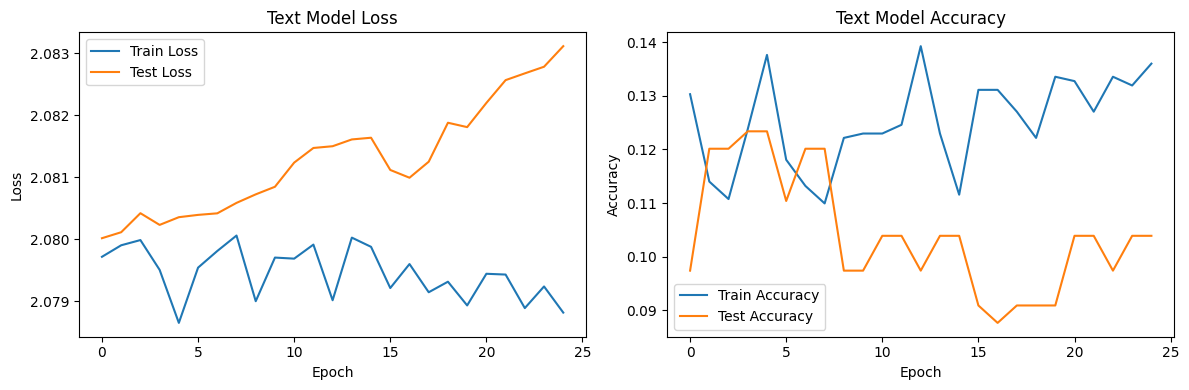

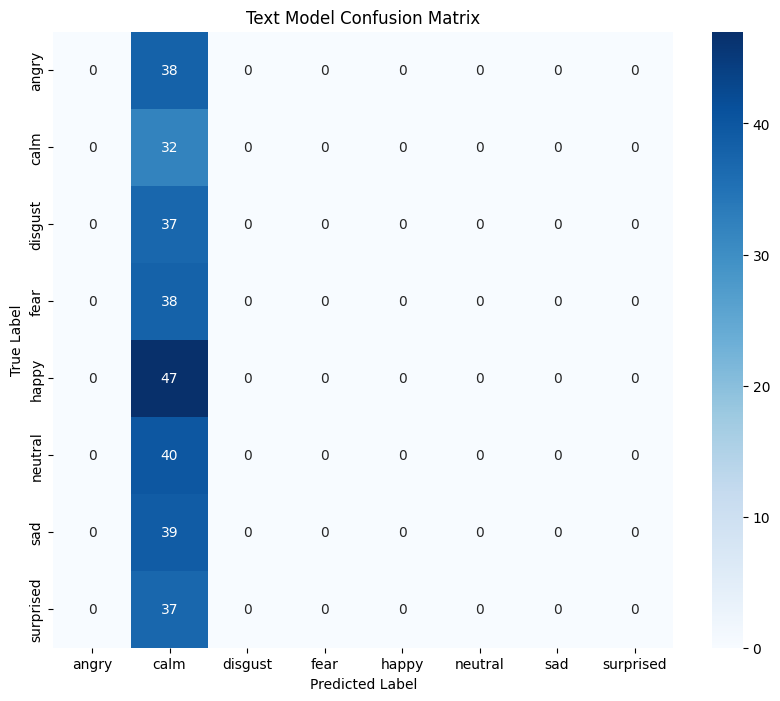

In [18]:
# Visualising

y_pred = np.argmax(text_model.predict(X_test_text), axis=1)
print(classification_report(y_test_text, y_pred, target_names=lb.classes_))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(results2.history['loss'], label='Train Loss')
plt.plot(results2.history['val_loss'], label='Test Loss')
plt.title('Text Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results2.history['accuracy'], label='Train Accuracy')
plt.plot(results2.history['val_accuracy'], label='Test Accuracy')
plt.title('Text Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

cm_text = confusion_matrix(y_test_text, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_text, annot=True, fmt='d', cmap='Blues',
            xticklabels=lb.classes_,
            yticklabels=lb.classes_)
plt.title('Text Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Accuracy:  13.9610%
              precision    recall  f1-score   support

       angry       0.17      0.18      0.18        38
        calm       0.12      0.22      0.15        32
     disgust       0.17      0.22      0.19        37
        fear       0.07      0.11      0.09        38
       happy       0.19      0.06      0.10        47
     neutral       0.12      0.03      0.04        40
         sad       0.14      0.10      0.12        39
   surprised       0.16      0.24      0.20        37

    accuracy                           0.14       308
   macro avg       0.14      0.14      0.13       308
weighted avg       0.15      0.14      0.13       308



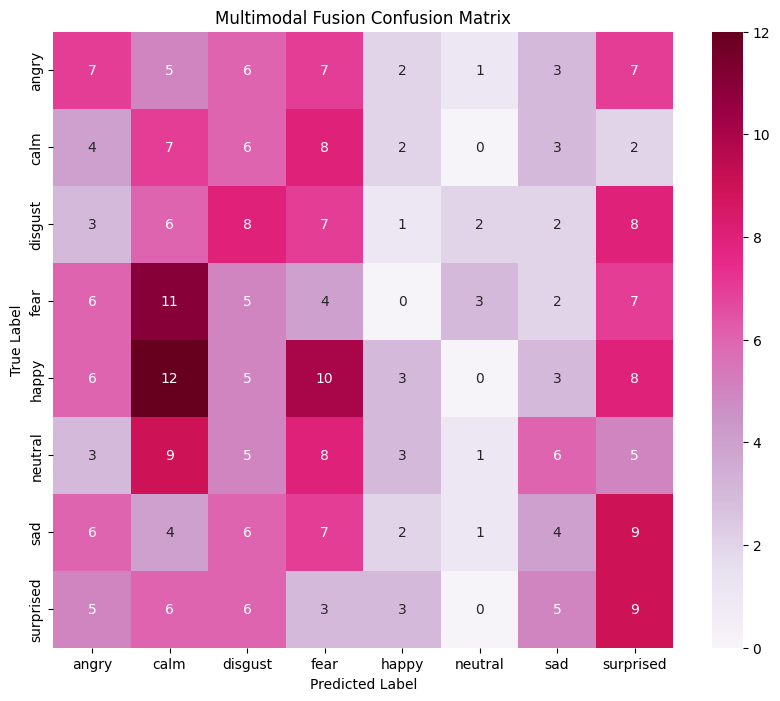

Model Comparison:
Audio CNN only: 59.4156%
Text LSTM only: 12.3377%
Multimodal fusion: 59.4156%


In [19]:
#multimodal fusion

# Getting just probabilities
audio_probs = CNN_model.predict(X_test)
text_probs = text_model.predict(X_test_text)

# Using weighted avg
y_pred_fused = np.argmax(0.7*audio_probs + 0.3*text_probs, axis=1)

print(f"Accuracy:  {accuracy_score(y_test_text, y_pred_fused)*100:.4f}%")
print(classification_report(y_test_text, y_pred_fused, target_names=lb.classes_))


cm = confusion_matrix(y_test_text, y_pred_fused)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',
            xticklabels=lb.classes_,
            yticklabels=lb.classes_)
plt.title('Multimodal Fusion Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# comparing all three models
audio_pred = np.argmax(audio_probs, axis=1)
text_pred = np.argmax(text_probs, axis=1)

print("Model Comparison:")
print(f"Audio CNN only: {accuracy_score(y_test, audio_pred)*100:.4f}%")
print(f"Text LSTM only: {accuracy_score(y_test, text_pred)*100:.4f}%")
print(f"Multimodal fusion: {accuracy_score(y_test, y_pred_fused)*100:.4f}%")